<a href="https://colab.research.google.com/github/shabnamsattar/Frank-Wolf-Algorithm-for-Recommender-Systems/blob/main/FW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os

import pandas as pd
import numpy as np

import scipy.sparse as sp
from scipy.sparse import csr_array
from scipy.sparse.linalg import svds

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, r2_score

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

from time import time
from tqdm import tqdm, trange

Load Netflix dataset

In [ ]:
#Download data from kaggle
path = kagglehub.dataset_download("netflix-inc/netflix-prize-data")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/netflix-inc/netflix-prize-data/versions/2


In [ ]:
Netflix_prize = pd.read_csv(os.path.join(path, "combined_data_1.txt"), header= None,
                            names= ['USER_ID', 'RATE'], usecols= [0,1],
                            dtype={'USER_ID': str, 'RATE': float})


In [ ]:
print(Netflix_prize.head(10))

   USER_ID  RATE
0       1:   NaN
1  1488844   3.0
2   822109   5.0
3   885013   4.0
4    30878   4.0
5   823519   3.0
6   893988   3.0
7   124105   4.0
8  1248029   3.0
9  1842128   4.0


In [ ]:
matching_row = Netflix_prize[(Netflix_prize['USER_ID'] == "101:") & (Netflix_prize['RATE'].isna())]
print(matching_row)

       USER_ID  RATE
352871    101:   NaN


In [ ]:
USER_RATINGS = Netflix_prize[:352871]

In [ ]:
# Extract indices of rows where 'Rate' is NaN
nan_indices = USER_RATINGS[USER_RATINGS['RATE'].isna()].index.tolist()

# Initialize a new column 'movie_Id' with default values
USER_RATINGS['MOVIE_ID'] = 0

# Assign movie IDs based on nan_indices
#nan_indices = df[df['Rate'].isna()].index.tolist()  # Assuming 'nan_indices' is defined this way
movie_id = 1

for i in range(len(nan_indices)):
    start = nan_indices[i] + 1
    end = nan_indices[i + 1] if i + 1 < len(nan_indices) else len(USER_RATINGS)
    USER_RATINGS.loc[start:end, 'MOVIE_ID'] = movie_id
    movie_id += 1

#Print the updated DataFrame
print(USER_RATINGS.shape)
print(USER_RATINGS.head(10))

(352871, 3)
   USER_ID  RATE  MOVIE_ID
0       1:   NaN         0
1  1488844   3.0         1
2   822109   5.0         1
3   885013   4.0         1
4    30878   4.0         1
5   823519   3.0         1
6   893988   3.0         1
7   124105   4.0         1
8  1248029   3.0         1
9  1842128   4.0         1


<ipython-input-7-187b6de1fba9>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  USER_RATINGS['MOVIE_ID'] = 0


In [ ]:
USER_RATINGS = USER_RATINGS.dropna(subset=['RATE']).reset_index(drop=True)
print(USER_RATINGS.shape)
print(USER_RATINGS.head(10))

(352771, 3)
   USER_ID  RATE  MOVIE_ID
0  1488844   3.0         1
1   822109   5.0         1
2   885013   4.0         1
3    30878   4.0         1
4   823519   3.0         1
5   893988   3.0         1
6   124105   4.0         1
7  1248029   3.0         1
8  1842128   4.0         1
9  2238063   3.0         1


In [ ]:
USER_RATINGS = USER_RATINGS.drop_duplicates(['USER_ID','MOVIE_ID'])
print(USER_RATINGS.shape)
print(USER_RATINGS.head(10))

(352771, 3)
   USER_ID  RATE  MOVIE_ID
0  1488844   3.0         1
1   822109   5.0         1
2   885013   4.0         1
3    30878   4.0         1
4   823519   3.0         1
5   893988   3.0         1
6   124105   4.0         1
7  1248029   3.0         1
8  1842128   4.0         1
9  2238063   3.0         1


start the algorithm

In [ ]:
def map_ids(ids, id_map):
    return [id_map[i] for i in ids]

In [ ]:
def gradient(X, U):
    X_dense = X.toarray()
    observed = U.toarray()
    grad = 2 * (X_dense - observed) * (observed != 0)
    return grad

In [ ]:
def linear_minimization_oracle(gradient, delta):

    u, s, vt = svds(gradient, k=1)
    u1, v1 = u[:, 0], vt[0, :]
    return delta * np.outer(u1, v1)

In [ ]:
def loss(X, U):
    """Compute the current loss (squared error)."""
    X_dense = X.toarray()
    observed = U.toarray()
    loss_value = np.sum((X_dense - observed) ** 2 * (observed != 0))
    return loss_value

In [ ]:
def frank_wolfe_matrix_completion(user_ids, movie_ids, ratings, rank, delta, max_iter=100, tol=1e-4):
    """
    Run the Frank-Wolfe optimization algorithm for matrix completion.

    Parameters:
    user_ids (array): Array of user IDs.
    movie_ids (array): Array of movie IDs.
    ratings (array): Array of ratings corresponding to user_id and movie_id pairs.
    rank (int): Rank constraint (δ in the optimization problem).
    delta (float): Nuclear norm ball constraint value.
    max_iter (int): Maximum number of iterations.
    tol (float): Tolerance for convergence.
    """
    values = []
    Dual_Gap = []
    # Map user and movie IDs to indices
    user_map = {uid: idx for idx, uid in enumerate(np.unique(user_ids))}
    movie_map = {mid: idx for idx, mid in enumerate(np.unique(movie_ids))}

    # Matrix dimensions
    num_users = len(user_map)
    num_movies = len(movie_map)

    # Sparse matrix for observed entries
    R = sp.coo_matrix((ratings, (map_ids(user_ids, user_map), map_ids(movie_ids, movie_map))),
                      shape=(num_users, num_movies))

    # Initialize X (low-rank approximation)
    X = sp.csr_matrix((num_users, num_movies))

    for iteration in range(1, max_iter + 1):
        grad = gradient(X, R)
        S = linear_minimization_oracle(-grad, delta)
        d_FW = S - X.toarray()

        # Compute step size using diminishing steps: alpha = 2 / (k + 1)
        alpha = 2 / (iteration + 1)

        # Update X
        X = X + alpha * sp.csr_matrix(d_FW)

        # Check for convergence

        duality_gap = np.sum(- np.dot(grad.T, d_FW))

        current_loss = loss(X, R)
        values.append(current_loss)
        Dual_Gap.append(duality_gap)
        print(f"Iteration {iteration}, Loss: {current_loss:.4f}, Dual_Gap: {duality_gap:.4f}")



        if current_loss < tol:
            print("Convergence achieved.")
            break

    return X, values, Dual_Gap

In [ ]:
user_ids = USER_RATINGS["USER_ID"].values
movie_ids = USER_RATINGS["MOVIE_ID"].values
ratings = USER_RATINGS["RATE"].values

In [ ]:
# Split into train and test sets
train_user_ids, test_user_ids, train_movie_ids, test_movie_ids, train_ratings,test_ratings = train_test_split (user_ids, movie_ids, ratings, test_size=0.2,
                                  random_state=42)

In [ ]:
rank = 1
delta = 500
max_iter = 10
tol = 1e-3

In [ ]:
# Run Frank-Wolfe matrix completion on the training set
completed_matrix, values, dual_gap = frank_wolfe_matrix_completion (train_user_ids, train_movie_ids,
                                                 train_ratings, rank, delta, max_iter, tol)

Iteration 1, Loss: 2996200.1840, Dual_Gap: 4194708.1535
Iteration 2, Loss: 2997964.8945, Dual_Gap: 2612445.9934
Iteration 3, Loss: 2988848.2660, Dual_Gap: -946629.1918
Iteration 4, Loss: 2985332.5283, Dual_Gap: 390034.8286
Iteration 5, Loss: 2983599.4958, Dual_Gap: 202792.6399
Iteration 6, Loss: 2982614.3054, Dual_Gap: 138522.8336
Iteration 7, Loss: 2982000.0130, Dual_Gap: 100620.9482
Iteration 8, Loss: 2981590.9932, Dual_Gap: 76375.8387
Iteration 9, Loss: 2981304.8863, Dual_Gap: 59939.5245
Iteration 10, Loss: 2981096.9030, Dual_Gap: 48288.5130


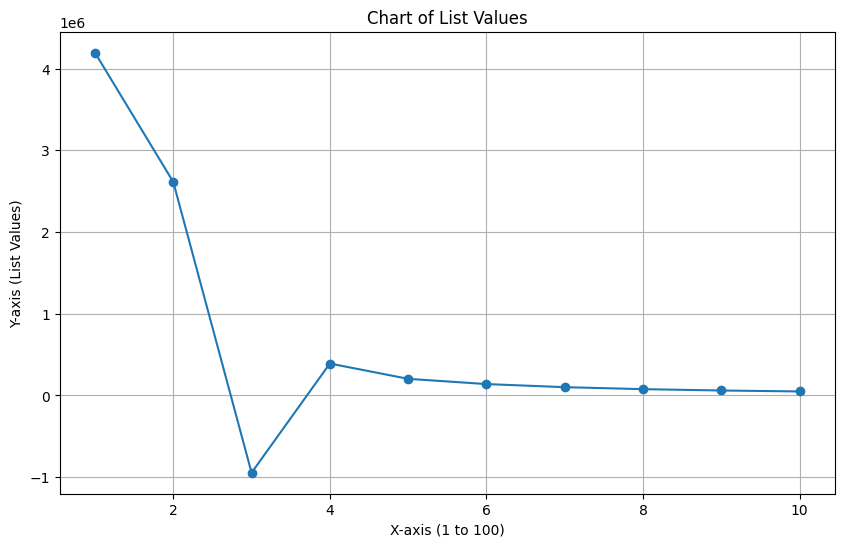

In [ ]:
import matplotlib.pyplot as plt

# Example list (replace with your actual list)


# Generate x-axis values from 1 to 100
x = list(range(1, 11))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, dual_gap, marker='o', linestyle='-')
plt.title('Chart of List Values')
plt.xlabel('X-axis (1 to 100)')
plt.ylabel('Y-axis (List Values)')
plt.grid(True)
plt.show()

In [ ]:
user_map = {uid: idx for idx, uid in enumerate(np.unique(test_user_ids))}
movie_map = {mid: idx for idx, mid in enumerate(np.unique(test_movie_ids))}

    # Matrix dimensions
num_users = len(user_map)
num_movies = len(movie_map)

# Sparse matrix for observed entries
TEST_M = sp.coo_matrix((test_ratings, (map_ids(test_user_ids, user_map), map_ids(test_movie_ids, movie_map))),
                      shape=(num_users, num_movies))

NameError: name 'np' is not defined